In [12]:
import pandas as pd

df = pd.DataFrame({'x0':[3, 2, 2, 3, 4, 9, 8, 8, 9, 10],
                   'x1':[1, 2, 3, 3, 2, 3, 4, 5, 5, 4]})

      0     1    2    3    4    5    6    7     8     9
0   0.0   2.0  3.0  2.0  2.0  8.0  8.0  9.0  10.0  10.0
1   2.0   0.0  1.0  2.0  2.0  8.0  8.0  9.0  10.0  10.0
2   3.0   1.0  0.0  1.0  3.0  7.0  7.0  8.0   9.0   9.0
3   2.0   2.0  1.0  0.0  2.0  6.0  6.0  7.0   8.0   8.0
4   2.0   2.0  3.0  2.0  0.0  6.0  6.0  7.0   8.0   8.0
5   8.0   8.0  7.0  6.0  6.0  0.0  2.0  3.0   2.0   2.0
6   8.0   8.0  7.0  6.0  6.0  2.0  0.0  1.0   2.0   2.0
7   9.0   9.0  8.0  7.0  7.0  3.0  1.0  0.0   1.0   3.0
8  10.0  10.0  9.0  8.0  8.0  2.0  2.0  1.0   0.0   2.0
9  10.0  10.0  9.0  8.0  8.0  2.0  2.0  3.0   2.0   0.0


<Axes: xlabel='x0', ylabel='x1'>

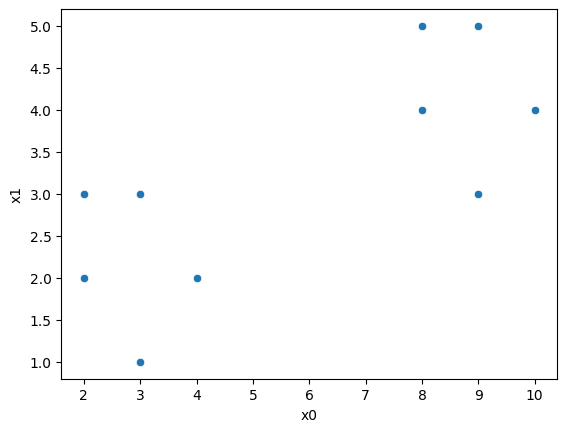

In [14]:
import seaborn as sns

sns.scatterplot(data=df, x="x0", y="x1")

,x0,x1,color
0,3,1,0
1,2,2,0
2,2,3,0
3,3,3,0
4,4,2,0
5,9,3,0
6,8,4,0
7,8,5,0
8,9,5,0
9,10,4,0


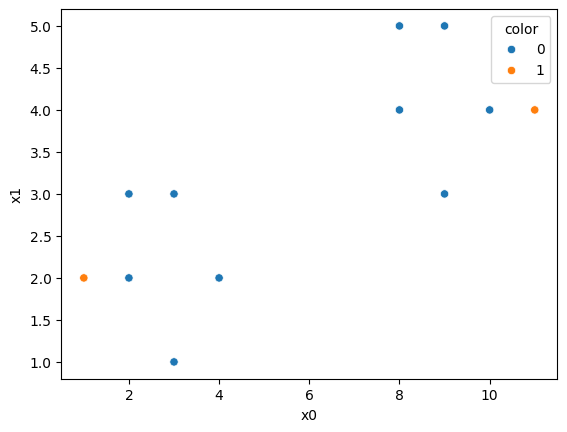

In [21]:
def plot_centroids(df, x_centr):
    data = df.copy()
    data['color'] = [0] * len(df)
    df_centroids = pd.DataFrame(x_centr, columns=df.columns)
    df_centroids['color'] = [1] * len(df_centroids)

    data = pd.concat([data, df_centroids], axis=0)

    sns.scatterplot(data=data, x='x0', y='x1', hue='color' )
    return data

my_centroids = [[1, 2], [11, 4]]
plot_centroids(df, my_centroids)

[[2 2]
 [4 2]]
0
1
2


(array([[2.8, 2.2],
        [8.8, 4.2]]),
 array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1]))

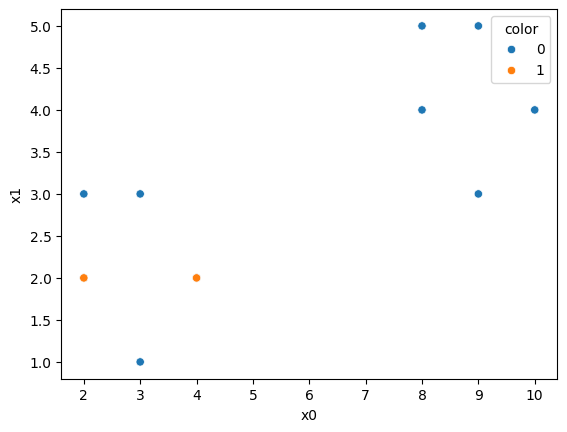

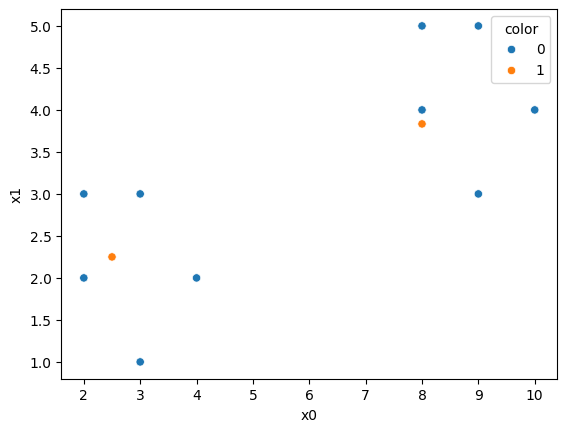

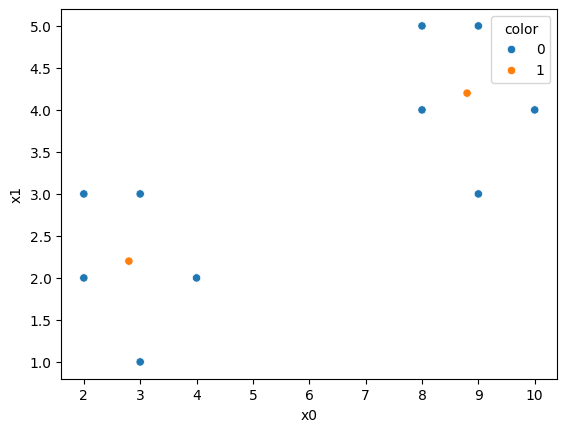

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def k_means(df, k, max_iters=100):
    # Отримуємо дані з DataFrame
    X = df[['x0', 'x1']].values

    # Ініціалізуємо центроїди випадковими точками
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    print(centroids)
    # plot_centroids(df, centroids)

    for iter in range(max_iters):
        print(iter)
        plt.figure(iter)
        plot_centroids(df, centroids)
        # Розрахунок відстаней між кожною точкою та центроїдами
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

        # Призначення кожної точки до найближчого центроїда
        labels = np.argmin(distances, axis=1)

        # Перерахунок центроїдів
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        # plot_centroids(df, new_centroids)

        # Перевірка збіжності
        if np.all(new_centroids == centroids):
            break

        centroids = new_centroids

    return centroids, labels

k_means(df, 2)